This notebook generates sensitivities to HERA and SKA using 21cmSense. I have been having trouble getting an SKA forecast that has higher sensitivity than HERA and want to figure out why, so I will try to replicate the data from 21cmfish and use the same settings on SKA.

## HERA

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as un
from astropy.cosmology import Planck18
from matplotlib import colors, rcParams

import py21cmsense as p21c
from py21cmsense.observatory import Observatory
from py21cmsense.sensitivity import PowerSpectrum
from py21cmsense.theory import EOS2021

%load_ext autoreload
%autoreload 2

rcParams.update({"font.size": 20})

In [148]:
# taken from SKA_forecast notebook in 21cmSense docs
def freq2z(f):
    """Convert frequency in MHz to redshift."""
    return 1420.4 / f - 1.0


def z2freq(z):
    """Convert redshift to frequency in MHz."""
    return 1420.4 / (z + 1.0)


def get_senses(
    observation,
    freq_bands,
    kperp_edges_hmpc,
    kpar_edges_hmpc,
    calc_2d=False,
    foreground_model="moderate",
    theory_model=EOS2021,
    **kwargs,
):
    """Calculate the sensitivity for a set of frequency bands."""
    h = observation.cosmo.H0.value / 100.0
    redshifts = kwargs["redshifts"]
    mock_senses = {}
    mock_senses["kperp_edges_hMpc"] = kperp_edges_hmpc
    mock_senses["kpar_edges_hMpc"] = kpar_edges_hmpc
    mock_senses["redshifts"] = redshifts
    mock_senses["freq_bands"] = freq_bands
    mock_senses["h"] = h
    HERA_hk = np.genfromtxt("/home/bakerem/21cmfish/examples/data/21cmSense_noise/21cmSense_fid_EOS21/klist_SplitCore_HERA350.drift_mod_0.054.txt")
    for _i, band, zval in zip(range(len(freq_bands)), freq_bands, redshifts):
        delta_21_theory = np.genfromtxt(f"/home/bakerem/21cmfish/examples/data/21cmSense_noise/21cmSense_fid_EOS21/P21model_SplitCore_HERA350.drift_mod_{band/1000:.3f}.txt")
        this_z = {}
        band_name = str(np.round(band, 1)) + " MHz"

        sense = PowerSpectrum(
            observation=observation, foreground_model=foreground_model,
        ).at_frequency(band * un.MHz)
        sense.k1d=  un.Quantity(HERA_hk, "littleh/Mpc")
        sense.delta_21 =delta_21_theory
        if calc_2d:
            sense2d_sample = sense.calculate_sensitivity_2d_grid(
                kperp_edges=kperp_edges_hmpc, kpar_edges=kpar_edges_hmpc, thermal=False, sample=True
            )
            this_z["sample_2D_mK2"] = sense2d_sample.value

            sense2d_thermal = sense.calculate_sensitivity_2d_grid(
                kperp_edges=kperp_edges_hmpc, kpar_edges=kpar_edges_hmpc, thermal=True, sample=False
            )
            this_z["thermal_2D_mK2"] = sense2d_thermal.value

            both = np.sqrt(sense2d_sample.value**2 + sense2d_thermal.value**2)
            this_z["sample_and_thermal_2D_mK2"] = both

        sense1d_sample = sense.calculate_sensitivity_1d(thermal=False, sample=True)
        this_z["sample_1D_mK2"] = sense1d_sample.value
        this_z["theory_1D_mK2"] = sense.theory_model.delta_squared(
            zval, sense.k1d.value * mock_senses["h"]
        ).value

        this_z["k_1D_Mpc"] = sense.k1d.value * mock_senses["h"]
        sense1d_thermal = sense.calculate_sensitivity_1d(thermal=True, sample=False)
        this_z["thermal_1D_mK2"] = sense1d_thermal.value

        sense1d_both = sense.calculate_sensitivity_1d(thermal=True, sample=True)
        this_z["sample_and_thermal_1D_mK2"] = sense1d_both.value
        mock_senses[band_name] = this_z
    return mock_senses

In [149]:
HERA_bins = np.array([27.4, 23.4828, 20.5152, 18.1892,
                16.3171, 14.7778, 13.4898, 12.3962, 11.4561,
                10.6393, 9.92308, 9.28986, 8.72603, 8.22078,
                7.76543, 7.35294, 6.97753, 6.63441, 6.31959,
                6.0297, 5.7619, 5.51376, 5.28319, 5.06838,
            ])
zs = (HERA_bins[:-1] + HERA_bins[1:])/2
freq_bands = z2freq(zs)
print(freq_bands)

[ 53.71878947  61.75920692  69.79098083  77.81670561  85.83799921
  93.85613659 101.87190705 109.88577419 117.89802203 125.90870289
 133.91825933 141.92723881 149.93553004 157.94322428 165.95037962
 173.95702634 181.9632922  189.969239   197.97495207 205.98045187
 213.98559469 221.99039615 229.99505326]


In [171]:
beam = p21c.GaussianBeam(frequency=150.0 * un.MHz, dish_size=14 * un.m)
HERA = Observatory(
            antpos=p21c.hera(hex_num=11, separation= 14 * un.m, row_separation=12.12 * un.m, split_core=False, outriggers=False),
            beam=beam,
            latitude= 30.8 * un.deg,
        )

HERA_obs = p21c.Observation(
    observatory=HERA,
    tsky_amplitude=60 * un.K,
    tsky_ref_freq=150 * un.MHz,
    spectral_index=2.55,
    # tsky_amplitude=60 * un.K,
    # tsky_ref_freq=300 * un.MHz,
    # spectral_index=2.55,
    n_days=180,
    time_per_day=6 * un.hour,
    bandwidth=8 * un.MHz,
    n_channels=82,
    integration_time=1* un.min, 
    lst_bin_size=HERA.beam.at(150 * un.MHz).fwhm.value * 12 / np.pi * 3600 * un.s,
    use_approximate_cosmo=True,
    cosmo=Planck18,
    # baseline_filters=p21c.BaselineRange(bl_min = 14.6 * un.m, bl_max=846 * un.m)
)
HERA.n_antennas

331

In [175]:
np.sqrt(np.genfromtxt("/home/bakerem/dark_photon_21cm_constraints/halo_data/hera79_data.csv")[:,1])

array([ 21.29030366,  21.29030366,  45.36495175,  50.78449659,
        77.93029408, 102.17325959, 126.53379753, 128.25324856,
       163.4794102 , 175.50265107, 199.50690989, 230.09893829,
       257.88421021])

In [172]:
# Only needed if we want to calculate the 2D sensitivity
# Set the kperp and kpar bins at which we want to calculate the 2D sensitivity
sense_params = {}
sense_params["calc_2d"] = False
# sense_params["foreground"] = "moderate"
sense_params["horizon_buffer"] = un.Quantity(0.15, "littleh/Mpc")
sense_params["redshifts"] = zs
sense_params["freq_bands"] = freq_bands
sense_params["kperp_edges_hmpc"] = un.Quantity(np.logspace(-1.5, 0.3, 15), "littleh/Mpc")
sense_params["kpar_edges_hmpc"] = un.Quantity(np.logspace(-1.5, 0.3, 15), "littleh/Mpc")
sense_params["kpar_mpc"] = (
    np.exp(
        (
            np.log(sense_params["kpar_edges_hmpc"].value[:-1])
            + np.log(sense_params["kpar_edges_hmpc"].value[1:])
        )
        / 2
    )
    * Planck18.h
)
sense_params["kperp_mpc"] = (
    np.exp(
        (
            np.log(sense_params["kperp_edges_hmpc"].value[:-1])
            + np.log(sense_params["kperp_edges_hmpc"].value[1:])
        )
        / 2
    )
    * Planck18.h
)

In [173]:
HERA_sense = get_senses(HERA_obs, **sense_params)

averaging to 1D: 100%|██████████| 158/158 [00:00<00:00, 313.31kperp-bins/s]


In [163]:
HERA_pess_sense = get_senses(HERA_obs, **sense_params)

averaging to 1D: 100%|██████████| 158/158 [00:00<00:00, 271.95kperp-bins/s]


In [156]:
HERA_pess_sense['53.7 MHz'].keys()

dict_keys(['sample_1D_mK2', 'theory_1D_mK2', 'k_1D_Mpc', 'thermal_1D_mK2', 'sample_and_thermal_1D_mK2'])

In [169]:
def compare_all_senses(senses, redshift=None, k=None, labels=None, colors=None, lss=None):
    """Plot the sensitivity of observations at a given z vs k and at a given k vs z."""
    # We assume all senses have the same redshifts / freq bands and k bins
    closest_redshift = np.argmin(np.abs(senses[0]["redshifts"] - redshift))
    band_name = str(np.round(z2freq(senses[0]["redshifts"][closest_redshift]), 1)) + " MHz"    
    # plot sens vs k at fixed z
    fig, ax = plt.subplots(
        1, 1, figsize=(12, 6), sharex=True, layout="constrained", gridspec_kw={"hspace": 0.05}
    )
    ax = [ax]
    Mhz_val = float(band_name.split(" ")[0])/1000
    hera_k = np.genfromtxt(f"/home/bakerem/21cmfish/examples/data/21cmSense_noise/21cmSense_pess_EOS21/klist_SplitCore_HERA350.drift_mod_0.054.txt")*Planck18.h
    hera_pess_err = np.genfromtxt(f"/home/bakerem/21cmfish/examples/data/21cmSense_noise/21cmSense_pess_EOS21/Errlist_SplitCore_HERA350.drift_mod_{Mhz_val:.3f}.txt")
    hera_err = np.genfromtxt(f"/home/bakerem/21cmfish/examples/data/21cmSense_noise/21cmSense_fid_EOS21/Errlist_SplitCore_HERA350.drift_mod_{Mhz_val:.3f}.txt")
    for i, sense in enumerate(senses):
        sensitivity_at_z = sense[band_name]["sample_and_thermal_1D_mK2"]
        m = np.isinf(sensitivity_at_z)
        ax[0].plot(
            sense[band_name]["k_1D_Mpc"][~m],
            sensitivity_at_z[~m],
            color=colors[i] if colors is not None else None,
            ls=lss[i] if lss is not None else None,
            label=labels[i] if labels is not None else None,
        )
    HERAm = np.isinf(hera_err)
    ax[0].plot(hera_k[~HERAm], hera_err[~HERAm], label="HERA", color="black", ls="--")
    ax[0].plot(hera_k[~np.isinf(hera_pess_err)], hera_pess_err[~np.isinf(hera_pess_err)], label="HERA", color="black", ls="-")

    ax[0].set_xlabel(r"k [Mpc$^{-1}$]")
    ax[0].set_ylabel(r"$\Delta^2_{21}$ [mK$^2$]")
    ax[0].set_yscale("log")
    ax[0].set_xscale("log")
    if labels is not None:
        plt.legend(frameon=False, fontsize=16)
    ylims = ax[0].get_ylim()
    xlims = ax[0].get_xlim()
    ax[0].text(xlims[1] * 0.3, ylims[1] * 0.35, "f = " + band_name, fontsize=20)
    ax[0].text(
        xlims[1] * 0.3,
        ylims[1] * 0.6,
        "z = " + str(np.round(senses[0]["redshifts"][closest_redshift])),
        fontsize=20,
    )
    ax[0].legend(["Pessimistic","Moderate", "Fish Moderate", "Fish Pessimistic"])
    plt.show()

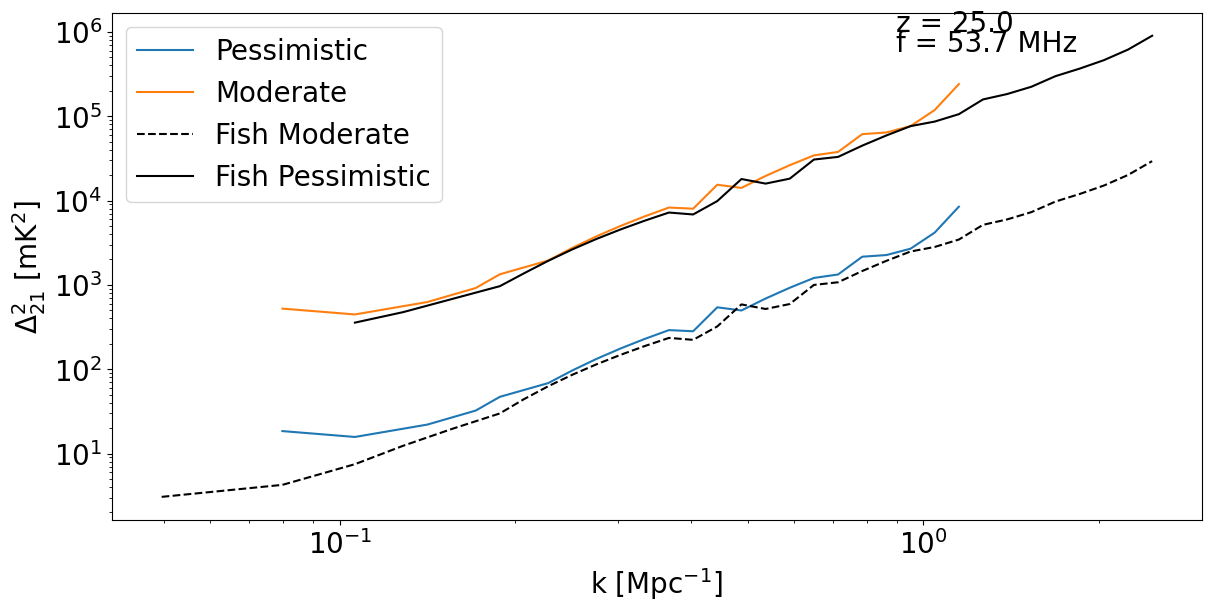

In [174]:
compare_all_senses([HERA_sense, HERA_pess_sense],
                   25, 
                   1
                   )
